<a href="https://colab.research.google.com/github/massimilianogasparini-author/creative-loop-dynamics/blob/main/Creative_Loop_Aggiornato_Simulazioni_e_grafici.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import ipywidgets as widgets
from IPython.display import display

# --- 1. DEFINIZIONE DELLE COSTANTI TERMODINAMICHE E INFORMAZIONALI ---
# Valori fissi come derivati dall'analisi dimensionale del sistema
K = 1.0       # Capacità di carico (saturazione) dell'informazione umana
K_s = 1.2     # Capacità di carico (overfitting) dell'informazione sintetica
gamma = 0.3   # Tasso intrinseco di crescita dell'IA (Dinamica di Gompertz)
lam = 0.1     # Fattore di soppressione umana sui dati sintetici
h_tau = 0.1   # Soglia MAD (Model Autophagy Disorder) - Orizzonte degli eventi

# --- 2. SISTEMA DI EQUAZIONI DIFFERENZIALI ORDINARIE (ODE) ---
def creative_loop_system(t, state, alpha, beta, phi):
    """
    Definisce il sistema di ODE accoppiate per h(t) e s(t).
    """
    h, s = state

    # Clamp per stabilità numerica: impedisce a h e s di scendere a zero assoluto
    # o a valori negativi, evitando divisioni per zero o logaritmi indefiniti.
    h = max(h, 1e-6)
    s = max(s, 1e-6)

    # Equazione 1: Dinamica dell'Informazione Umana
    dh_dt = alpha * h * (1.0 - h / K) - beta * h * s + phi

    # Equazione 2: Dinamica dell'Informazione Sintetica
    ds_dt = gamma * s * np.log(K_s / s) - lam * s * h

    return [dh_dt, ds_dt]

# --- 3. MOTORE DI SIMULAZIONE E RENDERING GRAFICO ---
def run_simulation(alpha, beta, phi):
    """
    Risolve il sistema e traccia il grafico al variare dei parametri interattivi.
    """
    # Condizioni iniziali del sistema [h0, s0]
    initial_state = [0.8, 0.1]

    # Discretizzazione temporale (da t=0 a t=100)
    t_span = (0, 100)
    t_eval = np.linspace(t_span[0], t_span[1], 1000)

    # Calcolo dell'integrale definito tramite Runge-Kutta
    solution = solve_ivp(
        creative_loop_system,
        t_span,
        initial_state,
        args=(alpha, beta, phi),
        t_eval=t_eval,
        method='RK45'
    )

    # Estrazione vettori risultati
    t = solution.t
    h_vals = solution.y[0]
    s_vals = solution.y[1]

    # Ricalcolo rigoroso della Soglia Critica di Iniezione (phi_crit)
    phi_crit = beta * h_tau * K_s - alpha * h_tau * (1 - h_tau / K)
    # Clamp visivo a zero se l'autorigenerazione è sufficiente senza iniezione esterna
    phi_crit_display = max(0, phi_crit)

    # Inizializzazione della figura
    plt.figure(figsize=(12, 6))

    # Tracciamento traiettorie di stato
    plt.plot(t, h_vals, label='Informazione Umana (h)', color='blue', linewidth=2.5)
    plt.plot(t, s_vals, label='Informazione Sintetica (s)', color='red', linewidth=2.5)

    # Tracciamento Soglia MAD
    plt.axhline(y=h_tau, color='black', linestyle='--', linewidth=1.5, label='Soglia MAD (h_tau = 0.1)')

    # Identificazione area di collasso autofago
    plt.fill_between(t, 0, h_tau, color='gray', alpha=0.2, label='Zona di Collasso (Autofagia)')

    # Analisi dello stato finale per l'allerta visiva
    if h_vals[-1] < h_tau:
        plt.title('STATO SISTEMA: COLLASSO AUTOFAGO IRREVERSIBILE', color='red', weight='bold', fontsize=14)
    else:
        plt.title('STATO SISTEMA: OMEOSTASI INFORMAZIONALE MANTENUTA', color='green', weight='bold', fontsize=14)

    # Formattazione assi e legenda
    plt.xlabel('Tempo (t)', fontsize=12)
    plt.ylabel('Volume Informazionale', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.ylim(0, 1.4)
    plt.xlim(0, 100)

    # Box testuale con calcolo analitico in tempo reale
    info_text = (f"Parametri Attuali:\n"
                 f"α (Crescita) = {alpha:.2f}\n"
                 f"β (Attrito) = {beta:.2f}\n"
                 f"φ (Iniezione) = {phi:.3f}\n"
                 f"-----------------\n"
                 f"φ_crit (Soglia Teorica) = {phi_crit_display:.3f}")

    plt.text(102, 0.7, info_text, bbox=dict(facecolor='white', edgecolor='black', alpha=0.9), fontsize=11, family='monospace')

    # Gestione del layout spaziale per evitare sovrapposizioni
    plt.subplots_adjust(right=0.8)
    plt.legend(loc='upper right')
    plt.show()

# --- 4. ISTANZIAZIONE INTERFACCIA WIDGET (COLAB) ---
# Costruzione formale degli slider secondo i range prestabiliti
alpha_slider = widgets.FloatSlider(value=0.5, min=0.1, max=1.0, step=0.05, description='α (Crescita Umana):', style={'description_width': 'initial'}, layout=widgets.Layout(width='500px'))
beta_slider = widgets.FloatSlider(value=0.4, min=0.0, max=1.0, step=0.05, description='β (Interferenza IA):', style={'description_width': 'initial'}, layout=widgets.Layout(width='500px'))
phi_slider = widgets.FloatSlider(value=0.05, min=0.0, max=0.5, step=0.01, description='φ (Iniezione Esterna):', style={'description_width': 'initial'}, layout=widgets.Layout(width='500px'))

# Binding della funzione di simulazione ai widget interattivi
interactive_plot = widgets.interactive(run_simulation, alpha=alpha_slider, beta=beta_slider, phi=phi_slider)
display(interactive_plot)

interactive(children=(FloatSlider(value=0.5, description='α (Crescita Umana):', layout=Layout(width='500px'), …

In [ ]:
# Importazione rigorosa delle librerie matematiche e di interfaccia
import numpy as np
from scipy.integrate import odeint
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# Funzione analitica per l'estrazione della soglia critica
# Questa funzione isola il calcolo di phi_crit per consentire ricalcoli dinamici
# nel caso in cui, in futuro, si desideri rendere interattivi anche altri parametri.
def calcola_soglia_critica(alpha, beta, gamma, lambd_, K, Ks):
    # Derivata della funzione di equilibrio phi(h)
    def dphi_dh(h):
        term1 = beta * Ks * np.exp(-(lambd_/gamma)*h) * (1 - (lambd_/gamma)*h)
        term2 = -alpha * (1 - 2*h/K)
        return term1 + term2

    # Ricerca del punto critico h_tau sul margine di sopravvivenza
    h_tau = fsolve(dphi_dh, 1.5)[0]

    # Valutazione della soglia di transizione di fase
    phi_crit = beta * h_tau * Ks * np.exp(-(lambd_/gamma)*h_tau) - alpha * h_tau * (1 - h_tau/K)
    return h_tau, phi_crit

# Motore di simulazione collegato all'interfaccia interattiva
def simulatore_interattivo_mad(phi):
    # 1. Definizione dei parametri termodinamici del sistema
    alpha, beta, gamma, lambd_, K, Ks = 0.5, 0.3, 0.4, 0.2, 10.0, 10.0

    # 2. Calcolo analitico vincolato (per ottenere il riferimento teorico)
    h_tau, phi_crit = calcola_soglia_critica(alpha, beta, gamma, lambd_, K, Ks)

    # 3. Definizione del sistema di equazioni differenziali
    def sistema_hs(y, t):
        h, s = y
        s_safe = max(s, 1e-6) # Prevenzione singolarità logaritmica

        dh_dt = alpha * h * (1 - h / K) - beta * h * s + phi
        ds_dt = gamma * s * np.log(Ks / s_safe) - lambd_ * s * h
        return [dh_dt, ds_dt]

    # 4. Integrazione Numerica
    t = np.linspace(0, 150, 2000)
    y0 = [1.0, 1.0] # Iniezione iniziale
    soluzione = odeint(sistema_hs, y0, t)

    h_dati = soluzione[:, 0]
    s_dati = soluzione[:, 1]

    # Valutazione dello stato finale (Equilibrio attrattivo)
    h_finale = h_dati[-1]
    stato_sistema = "COLLASSO INFORMAZIONALE (MAD)" if h_finale < 0.1 else "CREATIVE LOOP STABILE"
    colore_stato = "red" if h_finale < 0.1 else "green"

    # 5. Generazione del Layout Visivo
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # --- Grafico 1: Evoluzione Temporale ---
    ax1.plot(t, h_dati, 'b-', label='Informazione Umana (h)', linewidth=2.5)
    ax1.plot(t, s_dati, 'r--', label='Informazione Sintetica (s)', linewidth=2.5)
    ax1.axhline(0, color='black', linewidth=1)

    ax1.set_title('Evoluzione Temporale delle Dinamiche Informazionali', fontsize=12)
    ax1.set_xlabel('Tempo (Epoche)', fontsize=11)
    ax1.set_ylabel('Volume Informazionale', fontsize=11)
    ax1.grid(True, linestyle=':', alpha=0.7)
    ax1.legend(loc='upper right')

    # Annotazione testuale rigorosa dello stato
    ax1.text(0.05, 0.95, f'Stato: {stato_sistema}\n$\phi$ impostato: {phi:.2f}\n$\phi_{{crit}}$ teorico: {phi_crit:.3f}',
             transform=ax1.transAxes, fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', edgecolor=colore_stato, alpha=0.8))

    # --- Grafico 2: Ritratto di Fase e Geometria degli Attrattori ---
    ax2.plot(h_dati, s_dati, 'k-', label='Traiettoria del Sistema', linewidth=2)
    ax2.plot(h_dati[0], s_dati[0], 'go', markersize=8, label='Stato Iniziale')
    ax2.plot(h_dati[-1], s_dati[-1], 'ro', markersize=8, label='Attrattore Finale')

    # Tracciamento Nullcline per dimostrazione matematica
    h_vals_null = np.linspace(0.1, 15, 200)
    s_null_h = (alpha * (1 - h_vals_null/K) + phi) / beta # Nullclina dh/dt = 0

    s_vals_null = np.linspace(0.1, Ks, 200)
    h_null_s = (gamma / lambd_) * np.log(Ks / s_vals_null) # Nullclina ds/dt = 0

    ax2.plot(h_vals_null, s_null_h, 'b:', label='Nullclina dh/dt = 0', alpha=0.5)
    ax2.plot(h_null_s, s_vals_null, 'r:', label='Nullclina ds/dt = 0', alpha=0.5)

    ax2.set_title('Spazio delle Fasi (Ritratto di Fase)', fontsize=12)
    ax2.set_xlabel('Informazione Umana (h)', fontsize=11)
    ax2.set_ylabel('Informazione Sintetica (s)', fontsize=11)
    ax2.set_xlim(-0.5, 12)
    ax2.set_ylim(-0.5, 12)
    ax2.grid(True, linestyle=':', alpha=0.7)
    ax2.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

# Istanziazione dell'interfaccia Ipywidgets
# Lo slider trasmette il valore flottante direttamente al risolutore
interfaccia_phi = widgets.FloatSlider(
    value=0.5,
    min=0.0,
    max=5.0,
    step=0.05,
    description='Iniezione ($\phi$):',
    continuous_update=False, # Calcola al rilascio del mouse per non sovraccaricare il kernel
    layout=widgets.Layout(width='600px'),
    style={'description_width': 'initial'}
)

# Binding finale: unisce l'elemento UI alla funzione di integrazione
out = widgets.interactive_output(simulatore_interattivo_mad, {'phi': interfaccia_phi})

display(widgets.VBox([interfaccia_phi, out]))

<>:71: SyntaxWarning: invalid escape sequence '\p'
<>:71: SyntaxWarning: invalid escape sequence '\p'
<>:108: SyntaxWarning: invalid escape sequence '\p'
<>:71: SyntaxWarning: invalid escape sequence '\p'
<>:71: SyntaxWarning: invalid escape sequence '\p'
<>:108: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_4090/938384570.py:71: SyntaxWarning: invalid escape sequence '\p'
  ax1.text(0.05, 0.95, f'Stato: {stato_sistema}\n$\phi$ impostato: {phi:.2f}\n$\phi_{{crit}}$ teorico: {phi_crit:.3f}',
/tmp/ipykernel_4090/938384570.py:71: SyntaxWarning: invalid escape sequence '\p'
  ax1.text(0.05, 0.95, f'Stato: {stato_sistema}\n$\phi$ impostato: {phi:.2f}\n$\phi_{{crit}}$ teorico: {phi_crit:.3f}',
/tmp/ipykernel_4090/938384570.py:108: SyntaxWarning: invalid escape sequence '\p'
  description='Iniezione ($\phi$):',


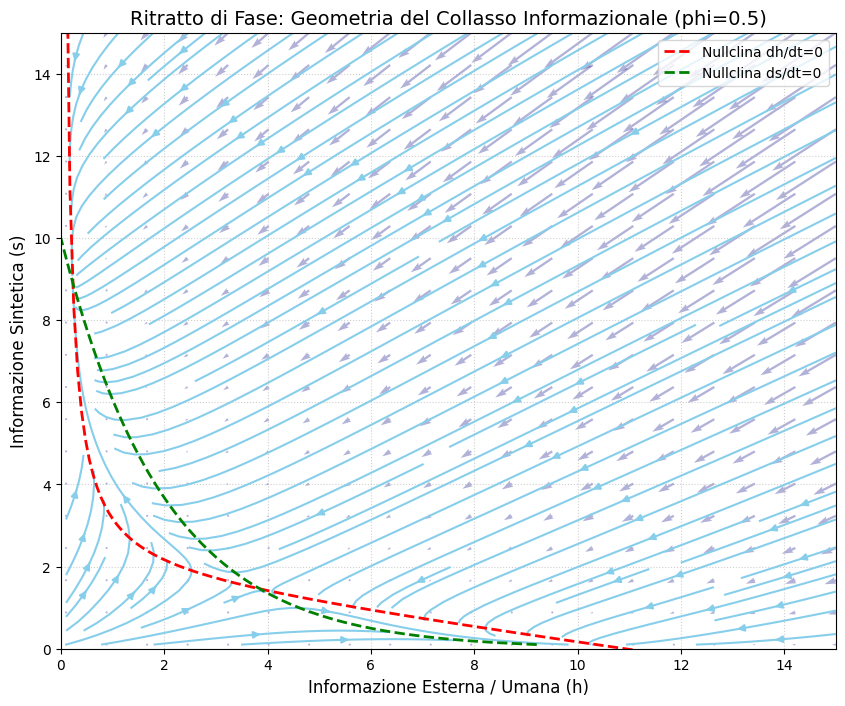

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parametri del sistema h-s
alpha, beta, gamma, lambd_, K, Ks = 0.5, 0.3, 0.4, 0.2, 10, 10
phi = 0.5 # Regime di bassa iniezione (Collasso)

def system(H, S):
    S_safe = np.maximum(S, 1e-6)
    dH = alpha * H * (1 - H/K) - beta * H * S + phi
    dS = gamma * S * np.log(Ks / S_safe) - lambd_ * S * H
    return dH, dS

h_range = np.linspace(0.1, 15, 20)
s_range = np.linspace(0.1, 15, 20)
H, S = np.meshgrid(h_range, s_range)
u, v = system(H, S)

plt.figure(figsize=(10, 8))
plt.streamplot(H, S, u, v, color='skyblue', density=1.5)
plt.quiver(H, S, u, v, color='navy', alpha=0.3)

# Nullclina dH/dt = 0
h_vals = np.linspace(0.1, 15, 200)
s_null_h = (alpha * (1 - h_vals/K) + phi/h_vals) / beta
plt.plot(h_vals, s_null_h, 'r--', label='Nullclina dh/dt=0', linewidth=2)

# Nullclina dS/dt = 0
s_vals = np.linspace(0.1, Ks, 200)
h_null_s = (gamma / lambd_) * np.log(Ks / s_vals)
plt.plot(h_null_s, s_vals, 'g--', label='Nullclina ds/dt=0', linewidth=2)

plt.title('Ritratto di Fase: Geometria del Collasso Informazionale (phi=0.5)', fontsize=14)
plt.xlabel('Informazione Esterna / Umana (h)', fontsize=12)
plt.ylabel('Informazione Sintetica (s)', fontsize=12)
plt.ylim(0, 15)
plt.xlim(0, 15)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

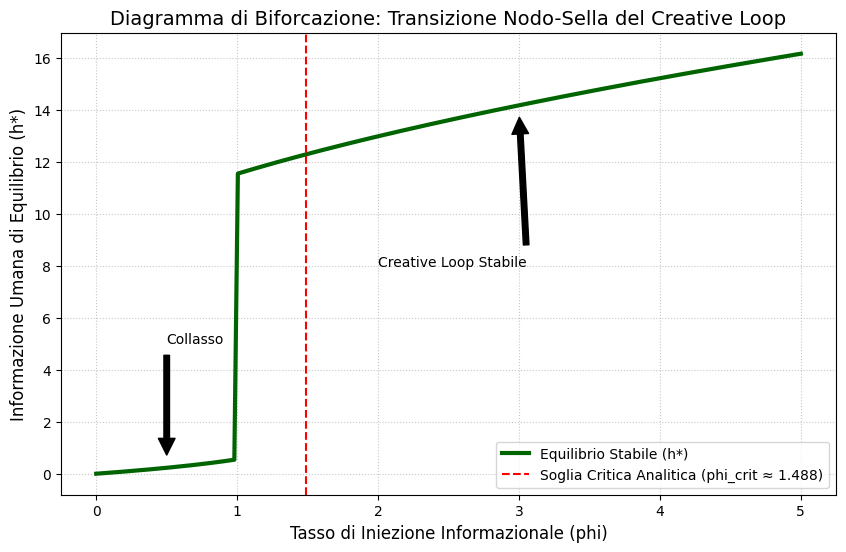

In [ ]:
import numpy as np
from scipy.integrate import odeint
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

# Parametri costanti
alpha, beta, gamma, lambd_, K, Ks = 0.5, 0.3, 0.4, 0.2, 10, 10

# 1. Derivazione analitica rigorosa della soglia critica (Biforcazione Nodo-Sella)
def dphi_dh(h):
    # Derivata rispetto ad h della funzione di equilibrio phi(h)
    term1 = beta * Ks * np.exp(-(lambd_/gamma)*h) * (1 - (lambd_/gamma)*h)
    term2 = -alpha * (1 - 2*h/K)
    return term1 + term2

# Trova il punto critico h_tau dove dphi/dh = 0
h_tau = fsolve(dphi_dh, 1.5)[0]

# Calcola il valore esatto della soglia critica
phi_crit = beta * h_tau * Ks * np.exp(-(lambd_/gamma)*h_tau) - alpha * h_tau * (1 - h_tau/K)

# 2. Simulazione del diagramma
def system(y, t, phi):
    h, s = y
    s_safe = max(s, 1e-6)
    dh = alpha*h*(1 - h/K) - beta*h*s + phi
    ds = gamma*s*np.log(Ks/s_safe) - lambd_*s*h
    return [dh, ds]

phi_values = np.linspace(0, 5, 200) # Range focalizzato sulla vera transizione
h_equilibria = []
t = np.linspace(0, 500, 2000)
y0 = [1.0, 1.0]

for phi in phi_values:
    sol = odeint(system, y0, t, args=(phi,))
    h_equilibria.append(sol[-1, 0])

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(phi_values, h_equilibria, color='darkgreen', linewidth=3, label='Equilibrio Stabile (h*)')

# Tracciamento rigoroso del valore calcolato dinamicamente
plt.axvline(x=phi_crit, color='red', linestyle='--', label=f'Soglia Critica Analitica (phi_crit ≈ {phi_crit:.3f})')

plt.title('Diagramma di Biforcazione: Transizione Nodo-Sella del Creative Loop', fontsize=14)
plt.xlabel('Tasso di Iniezione Informazionale (phi)', fontsize=12)
plt.ylabel('Informazione Umana di Equilibrio (h*)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

plt.annotate('Collasso', xy=(0.5, 0.5), xytext=(0.5, 5), arrowprops=dict(facecolor='black', shrink=0.05))
plt.annotate('Creative Loop Stabile', xy=(3, 14), xytext=(2, 8), arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

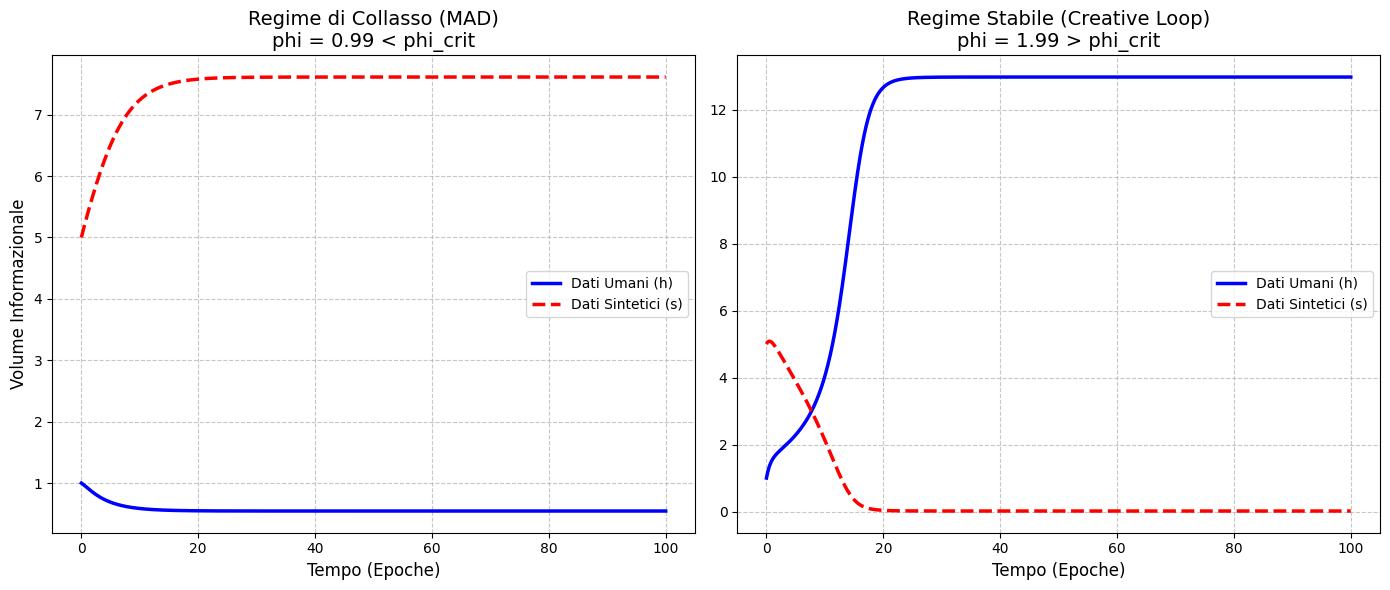

In [ ]:
import numpy as np
from scipy.integrate import odeint
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

# Parametri del Modello h-s
alpha, beta, gamma, lambd_, K, Ks = 0.5, 0.3, 0.4, 0.2, 10, 10

# Calcolo analitico in tempo reale della soglia critica di biforcazione
def dphi_dh(h):
    return beta * Ks * np.exp(-(lambd_/gamma)*h) * (1 - (lambd_/gamma)*h) - alpha * (1 - 2*h/K)

h_tau = fsolve(dphi_dh, 1.5)[0]
phi_crit = beta * h_tau * Ks * np.exp(-(lambd_/gamma)*h_tau) - alpha * h_tau * (1 - h_tau/K)

# Definizione del sistema differenziale
def creative_loop_system(y, t, phi):
    h, s = y
    s_safe = max(s, 1e-6)
    dh_dt = alpha * h * (1 - h / K) - beta * h * s + phi
    ds_dt = gamma * s * np.log(Ks / s_safe) - lambd_ * s * h
    return [dh_dt, ds_dt]

t = np.linspace(0, 100, 2000)

# CORREZIONE CRITICA: Condizioni Iniziali
# Impostiamo h=1.0 (Basso volume umano) e s=5.0 (Forte inquinamento sintetico preesistente).
# Questo colloca il sistema sotto forte stress per testare l'efficacia di phi.
y0 = [1.0, 5.0]

# Scenari agganciati alla soglia esatta calcolata
phi_collapse = phi_crit - 0.5  # Sotto la soglia -> La pressione sintetica s=5 vincerà
phi_stable = phi_crit + 0.5    # Sopra la soglia -> L'iniezione salverà il sistema da s=5

sol_collapse = odeint(creative_loop_system, y0, t, args=(phi_collapse,))
sol_stable = odeint(creative_loop_system, y0, t, args=(phi_stable,))

# Generazione dei grafici
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Grafico 1: MAD
ax1.plot(t, sol_collapse[:, 0], 'b-', label='Dati Umani (h)', linewidth=2.5)
ax1.plot(t, sol_collapse[:, 1], 'r--', label='Dati Sintetici (s)', linewidth=2.5)
ax1.set_title(f'Regime di Collasso (MAD)\nphi = {phi_collapse:.2f} < phi_crit', fontsize=14)
ax1.set_xlabel('Tempo (Epoche)', fontsize=12)
ax1.set_ylabel('Volume Informazionale', fontsize=12)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Grafico 2: Creative Loop
ax2.plot(t, sol_stable[:, 0], 'b-', label='Dati Umani (h)', linewidth=2.5)
ax2.plot(t, sol_stable[:, 1], 'r--', label='Dati Sintetici (s)', linewidth=2.5)
ax2.set_title(f'Regime Stabile (Creative Loop)\nphi = {phi_stable:.2f} > phi_crit', fontsize=14)
ax2.set_xlabel('Tempo (Epoche)', fontsize=12)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# Importazione delle librerie necessarie
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, clear_output

# Configurazione dello stile visivo per il grafico
sns.set_theme(style="white")

def calculate_and_visualize_cs(lz, embedding, perplexity, correlation, lambda_weight):
    """
    Funzione di callback che calcola il Creativity Score e aggiorna la UI
    ogni volta che uno slider viene mosso dall'utente.
    """
    # 1. Calcolo del Punteggio Base (Segnale)
    # Assumiamo pesi equi w_i = 1/3 per le tre metriche
    base_score = (lz + embedding + perplexity) / 3.0

    # 2. Creazione della Matrice di Covarianza 3x3
    # Sulla diagonale abbiamo la varianza normalizzata (1.0)
    # Fuori diagonale abbiamo la correlazione incrociata tra le metriche
    cov_matrix = np.array([
        [1.0, correlation, correlation],
        [correlation, 1.0, correlation],
        [correlation, correlation, 1.0]
    ])

    # 3. Calcolo della Norma di Frobenius della matrice off-diagonal
    # In una matrice 3x3, ci sono 6 elementi fuori diagonale.
    # Se tutti valgono 'correlation', la somma dei quadrati è 6 * correlation^2
    # La radice quadrata è sqrt(6) * correlation (circa 2.449 * correlation)
    frobenius_norm = np.sqrt(6) * correlation

    # 4. Calcolo della Penalità e del Punteggio Finale
    penalty = lambda_weight * frobenius_norm
    final_cs = max(0.0, base_score - penalty) # Il punteggio non può essere negativo

    # --- RENDERIZZAZIONE DELL'INTERFACCIA ---
    clear_output(wait=True) # Pulisce l'output precedente per evitare duplicati

    # Stampa dei risultati analitici
    print("="*50)
    print(" ANALISI IN TEMPO REALE: CREATIVITY SCORE (Cs)")
    print("="*50)
    print(f"Punteggio Base (Segnale Medio):  {base_score:.3f}")
    print(f"Penalità (Norma di Frobenius):  -{penalty:.3f}")
    print("-" * 50)
    print(f"PUNTEGGIO FINALE Cs:             {final_cs:.3f}")
    print("="*50)

    # Avviso termodinamico in caso di collasso
    if final_cs <= 0.0:
        print("\n⚠️ ATTENZIONE: COLLASSO AUTÒFAGO RILEVATO!")
        print("La ridondanza informativa ha annullato la validità del dato.")
        print("Il campione viene scartato per prevenire l'inquinamento del dataset.\n")
    else:
        print("\n✅ Dato validato. Procedere con l'iniezione (flusso φ).\n")

    # Rendering della Matrice di Covarianza
    fig, ax = plt.subplots(figsize=(6, 5))

    # Creiamo una maschera per isolare visivamente la diagonale (che è buona)
    # dagli elementi fuori diagonale (che rappresentano la ridondanza tossica)
    cmap = sns.light_palette("red", as_cmap=True)

    sns.heatmap(cov_matrix, annot=True, fmt=".2f", cmap=cmap, vmin=0, vmax=1,
                xticklabels=['LZ', 'Embedding', 'Perplexity'],
                yticklabels=['LZ', 'Embedding', 'Perplexity'],
                linewidths=.5, ax=ax, cbar_kws={'label': 'Livello di Ridondanza'})

    ax.set_title("Matrice di Covarianza (Σ)\n(L'intensità del rosso indica la penalità)", fontsize=12, pad=15)
    plt.tight_layout()
    plt.show()

# =====================================================================
# DEFINIZIONE DEGLI SLIDER INTERATTIVI (ipywidgets)
# =====================================================================
style = {'description_width': 'initial'}
layout = widgets.Layout(width='500px')

lz_slider = widgets.FloatSlider(value=0.8, min=0, max=1.0, step=0.01, description='Complessità LZ:', style=style, layout=layout)
embed_slider = widgets.FloatSlider(value=0.8, min=0, max=1.0, step=0.01, description='Dist. Embedding:', style=style, layout=layout)
perp_slider = widgets.FloatSlider(value=0.8, min=0, max=1.0, step=0.01, description='Perplexity:', style=style, layout=layout)

corr_slider = widgets.FloatSlider(value=0.1, min=0, max=1.0, step=0.01, description='Correlazione (Ridondanza):', style=style, layout=layout)
lambda_slider = widgets.FloatSlider(value=0.3, min=0, max=1.0, step=0.01, description='Peso Penalità (λ):', style=style, layout=layout)

# Creazione dell'interfaccia utente impilando i widget
ui = widgets.VBox([
    widgets.HTML("<b>Metriche Proxy (Il Segnale)</b>"),
    lz_slider, embed_slider, perp_slider,
    widgets.HTML("<br><b>Parametri di Penalizzazione (Il Rumore/Ridondanza)</b>"),
    corr_slider, lambda_slider
])

# Collegamento degli slider alla funzione di calcolo
out = widgets.interactive_output(calculate_and_visualize_cs, {
    'lz': lz_slider,
    'embedding': embed_slider,
    'perplexity': perp_slider,
    'correlation': corr_slider,
    'lambda_weight': lambda_slider
})

# Mostra l'interfaccia completa
display(ui, out)

Output()